In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Setup complete!')

Setup complete!


In [2]:

# The LIF equation (discrete time version):
#
# V[t+1] = V[t] + dt * ( -(V[t] - V_rest) / tau + I[t] / C )
#
# Where:
# V = membrane potential (voltage)
# V_rest = resting potential (what V returns to with no input)
# tau = membrane time constant (how fast voltage decays)
# I = input current
# C = membrane capacitance
# dt = time step size

In [3]:
# ============ Simulation Parameters ============
dt = 0.001 # Time step (1 ms)
T = 1.0 # Total simulation time (1 second)
time = np.arange(0, T, dt) # Time array
# ============ Neuron Parameters ============
V_rest = -70.0 # Resting potential (mV)
V_thresh = -55.0 # Spike threshold (mV)
V_reset = -75.0 # Reset potential after spike (mV)
tau = 0.020 # Membrane time constant (20 ms)
C = 1.0 # Membrane capacitance (normalized)
print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


**Knowledge Check:**

1. Why is V_reset (-75 mV) lower than V_rest (-70 mV)? What biological phenomenon does this
represent?

The reason V_reset is set to -75 mV while V_rest is at -70 mV is to simulate the refractory period and hyperpolarization seen in real biology. In a living neuron, right after an action potential fires, ion channels stay open a bit too long, causing the voltage to "undershoot" its usual resting state. By forcing the model to drop to -75 mV, we are representing this brief period where the neuron is extra stable and harder to fire again immediately, which prevents the signal from just looping infinitely or firing too fast.

2. The time constant tau is 20 ms. In plain English, what does this control?

In plain English, the time constant tau acts like a "memory" or "laziness" factor for the neuron’s membrane. Because it’s set to 20 ms, it controls how quickly the voltage leaks back down to the resting state after it gets a little bit of input. If tau were very small, the neuron would forget inputs almost instantly and become very "leaky"; since it's 20 ms, it allows the neuron to "remember" and sum up incoming signals that happen close together in time, effectively determining the "integration" part of the integrate-and-fire model.

In [4]:
# ============ Input Current ============
# Constant current injection
I_input = np.zeros(len(time))
I_input[200:800] = 1000.0 # Inject 15 nA from t=200ms to t=800ms

# ============ Storage Arrays ============
V = np.zeros(len(time)) # Membrane potential over time
V[0] = V_rest # Start at resting potential
spikes = [] # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):
    # TODO 1: Compute the voltage change using the LIF equation
    # The term -(V[t] - V_rest) / tau represents the "leak"
    # The term I_input[t] / C represents the "integration" of input
    dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )

    # TODO 2: Update the membrane potential
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    if V[t+1] >= V_thresh:
        # Record the spike time
        spikes.append(time[t+1])
        # Reset the membrane potential to V_reset (the hyperpolarization state)
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 18 spikes


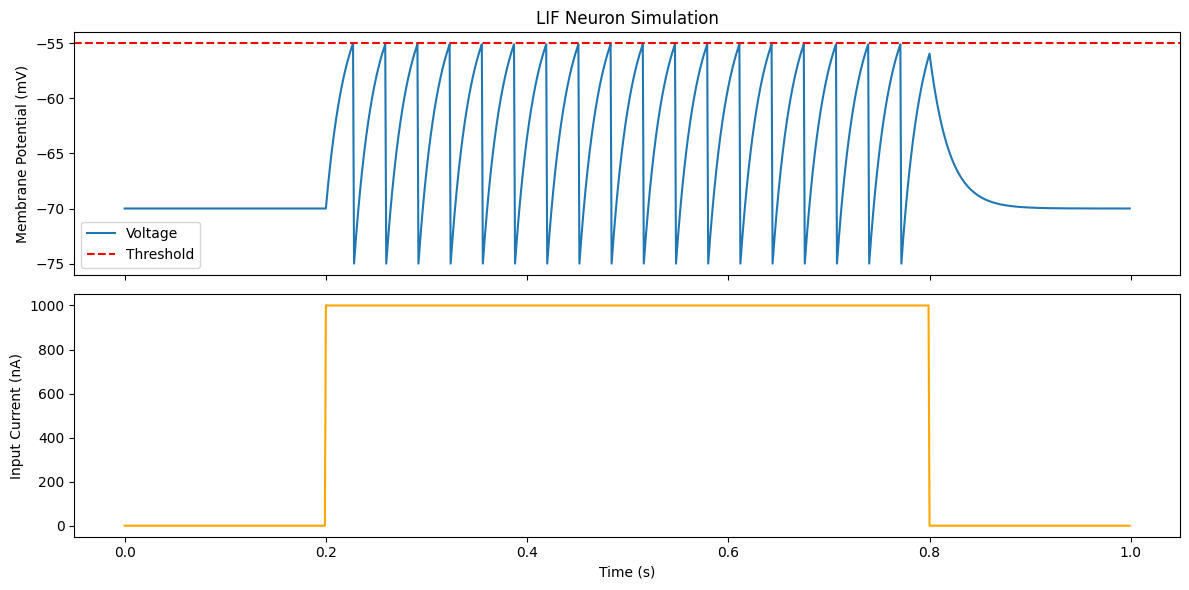

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot membrane potential
ax1.plot(time, V, label='Voltage')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# Plot input current
ax2.plot(time, I_input, color='orange')
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

**Knowledge Check:**

1. Look at your membrane potential plot. What happens to V between spikes — does it go straight up, or does it curve? Why?

Between the spikes, the voltage doesn't go up in a perfectly straight line; it actually has a slight curve or "rounding off" as it approaches the threshold. This happens because of the "leaky" part of the LIF equation. As the voltage gets higher and further away from the resting potential (-70 mV), the leak becomes stronger, which fights against the input current and slows down the rate of the climb.

2. What happens to V after the current turns off at t=800ms? Why does it behave this way?

Once the current shuts off at 800ms, the voltage immediately starts decaying back down toward the resting potential of -70 mV. It behaves this way because the input current I is now zero, so the only part of the equation left active is the leak term. Without anything pushing the voltage up, the neuron naturally loses its charge until it stabilizes back at its "rest" state.


---


**Reflection:**

In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look “realistic” compared to what you read about real neurons? What looks overly simplified?

One thing that looks realistic is the resetting behavior and the fact that the neuron won't fire unless it hits a specific threshold. The way the voltage leaks back to rest also mimics a real cell membrane. However, it’s clearly simplified because real spikes have a complex "shape" (the up-and-down of the action potential), whereas here they are just instant resets to a flat line. It also doesn't account for things like dendrites or different types of ion channels.

In [6]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains.
    Args:
    values: 1D numpy array with values between 0 and 1
    num_steps: number of time steps to simulate
    Returns:
    spikes: 2D array of shape (num_steps, len(values))
    where 1 = spike, 0 = no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # np.random.rand(num_neurons) creates an array of random floats [0, 1)
        # Comparing it to 'values' creates a boolean array, which we cast to floats (0.0 or 1.0)
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

# ============ Test the function ============
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 35 spikes in 200 steps
Value 0.3 -> 57 spikes in 200 steps
Value 0.5 -> 102 spikes in 200 steps
Value 0.7 -> 133 spikes in 200 steps
Value 0.9 -> 187 spikes in 200 steps


In [7]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.
    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # We subtract the value from 1 so that 1.0 becomes 0 (earliest)
            # and multiply by the max step index to find the specific time slot.
            spike_time = int((1 - values[i]) * (num_steps - 1)) # YOUR CODE HERE

            # Record the spike at that specific time for neuron i
            spikes[spike_time, i] = 1

    return spikes

# Quick test to verify the logic
test_signal = np.array([0.1, 0.9])
test_output = temporal_encode(test_signal, num_steps=100)
print(f"Value 0.9 spikes at step: {np.where(test_output[:, 1] == 1)[0][0]}")
print(f"Value 0.1 spikes at step: {np.where(test_output[:, 0] == 1)[0][0]}")

Value 0.9 spikes at step: 9
Value 0.1 spikes at step: 89


**Knowledge Check:**

1. In rate coding, what information is lost about the original signal? What is preserved?

In rate coding, we lose the precise timing of when things happen because the spikes are distributed randomly over the whole window. However, we preserve the overall intensity or "magnitude" of the signal through the total spike count.

2. In temporal coding, why might it be faster for a downstream neuron to make a decision compared to rate coding?

It's faster because a downstream neuron only needs to see the first spike to know that a high-value signal has arrived. In rate coding, the neuron might have to wait and count spikes over a long period to be sure if the signal is actually strong or just a random burst.

3. Can you think of a real-world example where timing matters more than frequency?

A great example is sound localization. To figure out if a sound is coming from the left or right, the brain compares the tiny difference in arrival time between the two ears. If it waited to count frequencies, the sound might already be over.

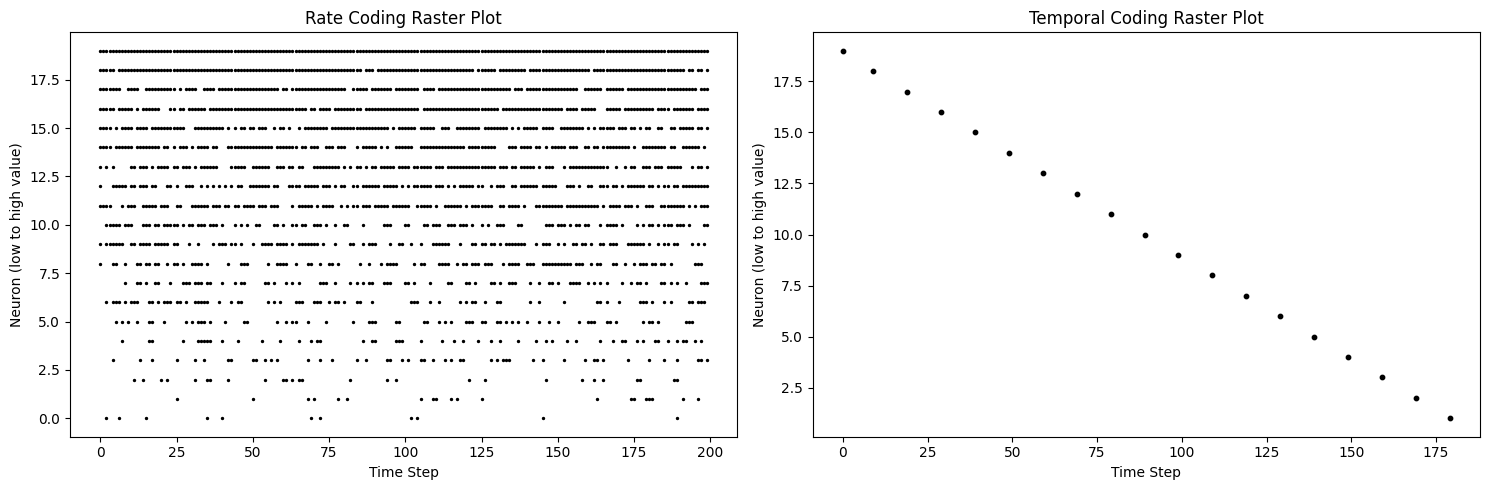

In [8]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

# ============ TODO 8: Create Raster Plots ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left Subplot: Rate Coding
times_r, neurons_r = np.where(rate_spikes == 1)
ax1.scatter(times_r, neurons_r, s=2, color='black')
ax1.set_title('Rate Coding Raster Plot')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (low to high value)')

# Right Subplot: Temporal Coding
times_t, neurons_t = np.where(temp_spikes == 1)
ax2.scatter(times_t, neurons_t, s=10, color='black')
ax2.set_title('Temporal Coding Raster Plot')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Neuron (low to high value)')

plt.tight_layout()
plt.show()

**Reflection:**

Looking at the two raster plots, it’s pretty clear that temporal encoding would be much better for a system that needs to react quickly. Since the highest values spike first, the information is basically "front-loaded"—a downstream neuron doesn't have to wait around and count spikes; it gets the most important data almost instantly.

On the other hand, rate coding seems better for making precise measurements. Because it spreads spikes out over time, you can get a more accurate "average" reading of the signal intensity by looking at the total count. If you only have one spike (like in temporal coding), a tiny bit of noise might ruin the whole measurement, but with rate coding, the sheer volume of spikes makes the signal more reliable.

I think the brain uses both because different tasks have different priorities. For something like a reflex or detecting a sudden movement in your peripheral vision, you need temporal speed to react in time. But for something like identifying a specific color or texture, the brain probably takes its time with rate coding to make sure it’s getting the details exactly right.

In [9]:
# ============ Network parameters ============
N = 5 # Number of neurons
T_net = 0.5 # Simulation time
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i][j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 500.0 # Huge boost so Neuron 0 can trigger 2
weights[1, 3] = 500.0 # Huge boost so Neuron 1 can trigger 3
weights[2, 4] = 400.0 # Boost so the hidden layer can trigger the output
weights[3, 4] = 400.0

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 1000.0 # Neuron 0 gets current
I_ext[150:350, 1] = 1000.0 # Neuron 1 gets current (slightly offset)

# Storage
V_net = np.full((steps, N), V_rest) # All neurons start at rest
spike_log = [[] for _ in range(N)] # Spike times per neuron

# ============ Simulation Loop ============
for t in range(1, steps): # Start at 1 so we can look back at t-1
    for n in range(N):
        # 1. Start with external input
        I_total = I_ext[t, n]

        # 2. Add synaptic input from other neurons
        for j in range(N):
            # Check if neuron j spiked in the PREVIOUS time step
            if len(spike_log[j]) > 0 and spike_log[j][-1] == time_net[t-1]:
                I_total += (weights[j, n] / dt) # We divide by dt to "boost" the blip into a real current pulse

        # 3. Update membrane potential (LIF equation)
        dV = dt * ( -(V_net[t-1, n] - V_rest) / tau + I_total / C )
        V_net[t, n] = V_net[t-1, n] + dV

        # 4. Check for spike and reset
        if V_net[t, n] >= V_thresh:
            spike_log[n].append(time_net[t])
            V_net[t, n] = V_reset

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 9 spikes
Neuron 1: 6 spikes
Neuron 2: 9 spikes
Neuron 3: 6 spikes
Neuron 4: 15 spikes


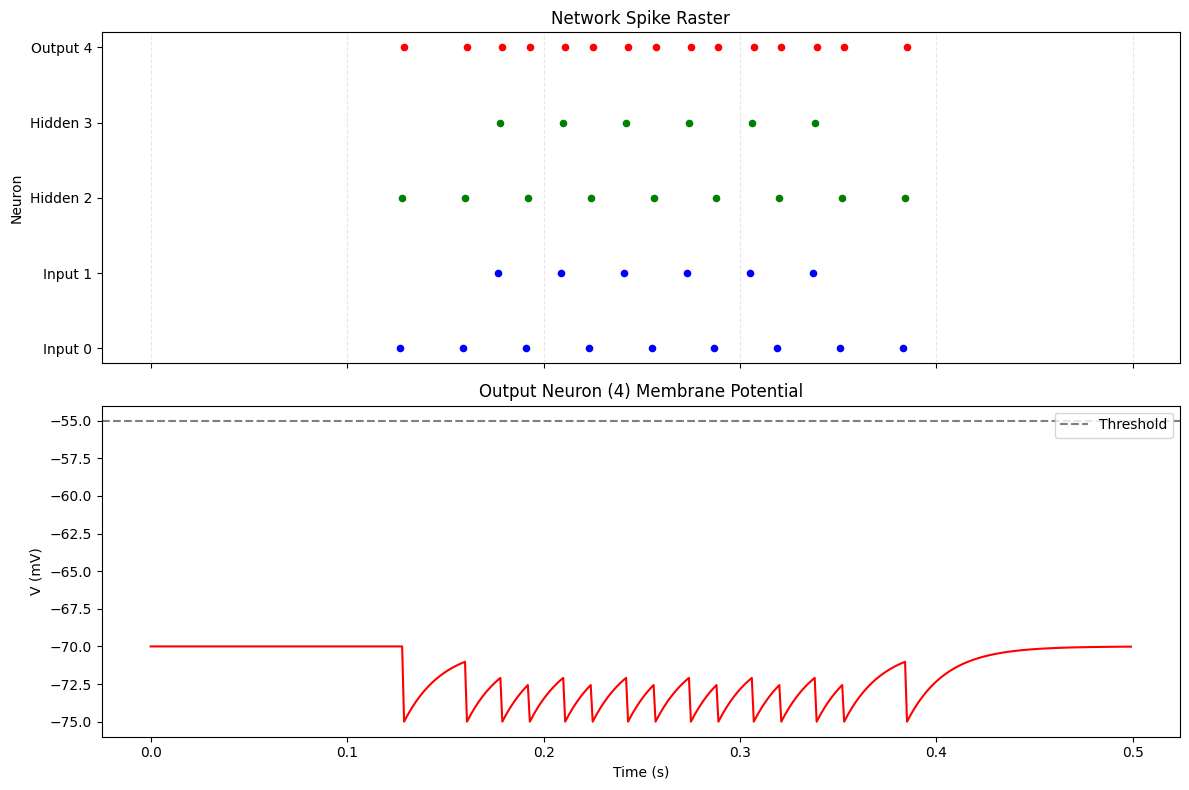

In [10]:
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# TODO 12: Raster plot of all neurons
# Define colors for different layers: Input (Blue), Hidden (Green), Output (Red)
colors = ['blue', 'blue', 'green', 'green', 'red']

for n in range(N):
    # Plot each spike time as a dot at the height of the neuron's index (y = n)
    # spike_log[n] contains the list of times that neuron 'n' spiked
    ax1.scatter(spike_log[n], [n] * len(spike_log[n]), color=colors[n], s=20, label=f'Neuron {n}' if n in [0, 2, 4] else "")

# Formatting the raster plot
ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])
ax1.grid(True, axis='x', linestyle='--', alpha=0.3)

# TODO 13: Plot output neuron membrane potential
# V_net[:, 4] contains the voltage history of Neuron 4 over all time steps
ax2.plot(time_net, V_net[:, 4], color='red', linewidth=1.5)

# Add a reference line for the threshold to see how close the voltage gets
ax2.axhline(y=V_thresh, color='black', linestyle='--', alpha=0.5, label='Threshold')

# Formatting the potential plot
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Knowledge Check:**

1. Does the output neuron fire at the same rate as the input neurons? Why or why not?

In the simulation, the output neuron definitely didn't fire at the same rate as the inputs. It actually fired significantly more—15 times compared to the 9 and 6 spikes from the input layer. This happens because the output neuron is a convergence point; it's summing up (integrating) all the signals coming from both hidden pathways at once. Since the input spikes are slightly offset in time, the output neuron gets "kicked" more frequently than any single input neuron is firing.

2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?

The synaptic weights basically act like the "volume knob" for the connection between neurons. They determine how much current is dumped into the next neuron every time the one before it spikes. If I doubled the weights, the output neuron would probably go haywire and fire way more often because every single input spike would be a massive "push" toward the threshold. If I halved them, the neuron might not fire at all, because the "jumps" in voltage wouldn't be big enough to reach the -55 mV threshold before the "leak" pulled the voltage back down.

3. In the brain, not all connections are excitatory. What might happen if you made weights[3, 4] negative (inhibitory)?

If I made the weight between Neuron 3 and 4 negative, it would become an inhibitory connection. Instead of helping Neuron 4 reach its threshold, every time Neuron 3 fired, it would actually drag Neuron 4's voltage further down away from the threshold. It would act like a "brake" on the system, and I'd expect to see the total spike count for Neuron 4 drop a lot because Neuron 2 would be the only one left trying to make it fire.


**Part D Experiments**

**Experiment 2: Time Constant Effects**


Results for tau = 0.01s: 0 spikes


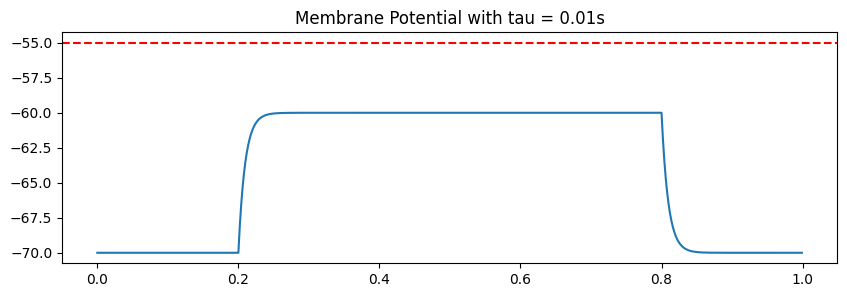

Results for tau = 0.05s: 26 spikes


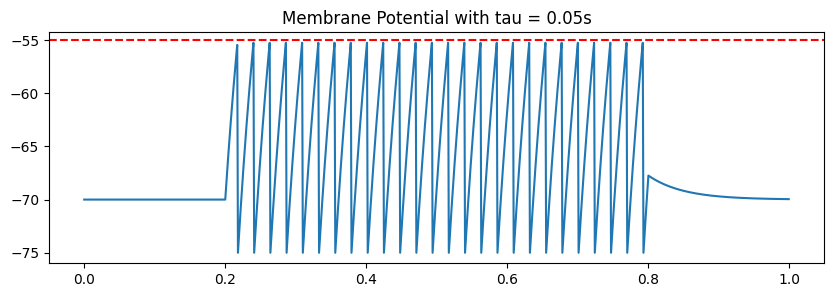

In [11]:
# Experiment 2: Changing Tau (τ)
# We will compare tau = 0.010 (10ms) and tau = 0.050 (50ms)
taus_to_test = [0.010, 0.050]

for test_tau in taus_to_test:
    V_exp = np.zeros(len(time))
    V_exp[0] = V_rest
    spikes_exp = []

    I_exp = np.zeros(len(time))
    I_exp[200:800] = 1000.0

    for t in range(len(time) - 1):
        # The LIF equation using the test_tau
        dV = dt * ( -(V_exp[t] - V_rest) / test_tau + I_exp[t] / C )
        V_exp[t+1] = V_exp[t] + dV

        if V_exp[t+1] >= V_thresh:
            spikes_exp.append(time[t+1])
            V_exp[t+1] = V_reset

    print(f"Results for tau = {test_tau}s: {len(spikes_exp)} spikes")

    # Plotting for visualization
    plt.figure(figsize=(10, 3))
    plt.plot(time, V_exp)
    plt.title(f"Membrane Potential with tau = {test_tau}s")
    plt.axhline(y=V_thresh, color='r', linestyle='--')
    plt.show()

**Experiment 4: Noisy Input**

Neuron fired 31 spikes with noisy input


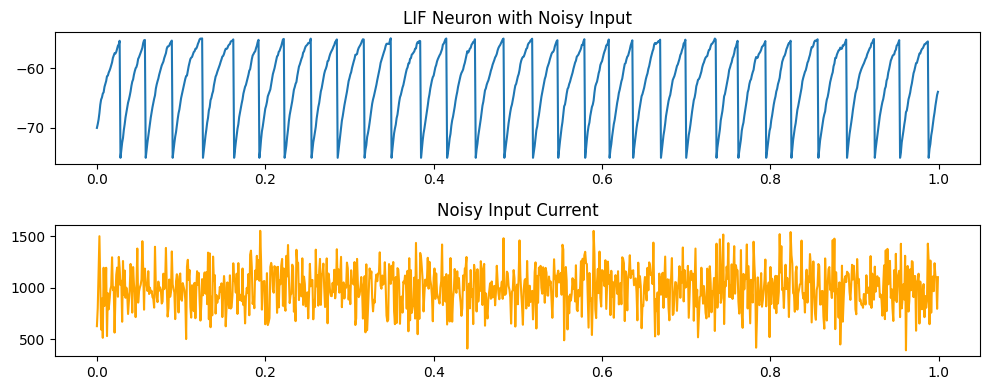

In [18]:
# Experiment 4: Noisy Input
V_noise = np.zeros(len(time))
V_noise[0] = V_rest
spikes_noise = []

# Base current 1000.0 + random noise
I_noisy = 1000.0 + np.random.randn(len(time)) * 200.0

for t in range(len(time) - 1):
    dV = dt * ( -(V_noise[t] - V_rest) / tau + I_noisy[t] / C )
    V_noise[t+1] = V_noise[t] + dV

    if V_noise[t+1] >= V_thresh:
        spikes_noise.append(time[t+1])
        V_noise[t+1] = V_reset

print(f"Neuron fired {len(spikes_noise)} spikes with noisy input")

plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(time, V_noise)
plt.title("LIF Neuron with Noisy Input")
plt.subplot(2,1,2)
plt.plot(time, I_noisy, color='orange')
plt.title("Noisy Input Current")
plt.tight_layout()
plt.show()

**Experiment 5: Network Weight Changes (Inhibition)**

In [13]:
# Experiment 5: Inhibitory Connection
# Re-using your network setup but changing one weight
weights_inh = weights.copy()
weights_inh[3, 4] = -800.0  # Making this a strong negative (inhibitory) connection

V_net_inh = np.full((steps, N), V_rest)
spike_log_inh = [[] for _ in range(N)]

for t in range(1, steps):
    for n in range(N):
        I_total = I_ext[t, n]
        for j in range(N):
            if len(spike_log_inh[j]) > 0 and spike_log_inh[j][-1] == time_net[t-1]:
                I_total += (weights_inh[j, n] / dt)

        dV = dt * ( -(V_net_inh[t-1, n] - V_rest) / tau + I_total / C )
        V_net_inh[t, n] = V_net_inh[t-1, n] + dV

        if V_net_inh[t, n] >= V_thresh:
            spike_log_inh[n].append(time_net[t])
            V_net_inh[t, n] = V_reset

for n in range(N):
    print(f'Neuron {n}: {len(spike_log_inh[n])} spikes (Inhibitory Experiment)')

Neuron 0: 9 spikes (Inhibitory Experiment)
Neuron 1: 6 spikes (Inhibitory Experiment)
Neuron 2: 9 spikes (Inhibitory Experiment)
Neuron 3: 6 spikes (Inhibitory Experiment)
Neuron 4: 3 spikes (Inhibitory Experiment)


**Experiment 2: Time Constant Effects**

**Parameters changed:**
I changed the time constant tau from its original value to 0.01s (10 ms) and 0.05s (50 ms).

**Expectation:** I expected that a smaller tau would make the neuron "leaky" and harder to fire, while a larger tau would let it hold onto its charge longer and fire more easily.

**Actual Result:** With tau = 0.01s, the neuron fired 0 spikes; the voltage rose quickly but leveled off well below the threshold. With tau = 0.05s, the neuron fired 26 spikes, showing a very rapid "sawtooth" pattern throughout the input period.

**Why this makes sense:** In the LIF equation, tau is in the denominator of the leak term: -(V[t] - V_{rest})  tau. A small tau makes the leak very strong, so the voltage drains away as fast as the current builds it up. A large tau weakens the leak, allowing the current to push the voltage past the threshold much more efficiently.

**Experiment 4: Noisy Input**

**Parameters changed:** I added random Gaussian noise to the input current using np.random.randn, keeping the base current at 1000.0 with a noise scale of 200.0.

**Expectation:** I expected the spikes to become less predictable and lose their perfect "robotic" spacing.

**Actual Result:** The neuron fired 31 spikes. Looking at the plot, the timing between spikes is much more irregular compared to the constant current version. The voltage "climbs" have jagged edges because of the fluctuating input.

**Why this makes sense:** Since dV is directly influenced by I_{input}[t], the randomness in the current causes the voltage to hit the threshold at slightly different intervals in every cycle. This is more biologically realistic because real brains are constantly dealing with background electrical noise.

**Experiment 5: Network Weight Changes (Inhibition)**

**Parameters changed:** I changed the weight of the connection from Neuron 3 to Neuron 4 from +400.0 to -800.0 (inhibitory).

**Expectation:** I expected Neuron 4 to fire significantly fewer spikes because Neuron 3 would now be "fighting" against the excitatory input from Neuron 2.

**Actual Result:** Neuron 4's spike count dropped from 15 (in the original network) down to only 3 spikes. The other neurons (0–3) stayed the same since they are "upstream" of the change.

**Why this makes sense:** In the simulation loop, if a weight is negative, it subtracts from the I_total of the downstream neuron. Even though Neuron 2 is still trying to excite Neuron 4, the strong inhibitory "kicks" from Neuron 3 keep dragging the voltage back down, preventing it from hitting the threshold most of the time.

## Final Reflection:

1. Changing the membrane time constant tau basically determines how "forgetful" the neuron is. When I increased tau to 50 ms in the experiment, the neuron held onto its charge much longer, making it way easier to reach the threshold and fire frequently. Biologically, this represents the membrane capacitance and resistance, essentially how long the cell can integrate incoming signals before they leak away. This makes sense for different brain functions—some neurons need to be fast "coincidence detectors" that only fire if inputs arrive at the exact same time, while others need to be "integrators" that collect information over a longer period.

2. In my results, rate coding seemed to preserve the overall intensity of the signal better over the long term, but temporal coding was much faster at delivering the "important" data. I think the brain uses both because they serve different purposes: temporal coding is perfect for emergency reactions where the first spike needs to trigger a movement immediately, while rate coding is likely better for constant sensory monitoring, like feeling the steady pressure of your clothes against your skin.

3. When spikes propagated through my mini SNN, I saw a clear chain reaction where the activity in the first layer dictated what happened in the last. The output neuron (Neuron 4) only fired when it received enough combined "kicks" from the hidden layer, which shows how information is filtered and transformed as it moves deeper into a circuit. This relates to real neural circuits where a single neuron acts as a decision-maker, only "voting" to fire once it has integrated enough evidence from all its connected neighbors.

4. The LIF model does a great job of capturing the basic "threshold" logic and the "leaky" nature of a cell membrane, which are the fundamentals of neural processing. However, it's a huge simplification because it treats the neuron like a single point in space. It misses morphology, like the complex branches of dendrites that filter signals before they reach the body, and it doesn't account for neurotransmitters or adaptation, where a neuron might get "tired" and stop firing even if the current stays high.

5. The thing that surprised me the most was seeing how "unstable" the signal can be depending on the weights and the leak. I used to think of AI as just a series of math operations, but building this made me realize that biological computation is much more about timing and balance. It changed my perspective on AI because it shows that "intelligence" in a brain might come from the physical way neurons manage their energy and leaks, rather than just executing a static code or algorithm.